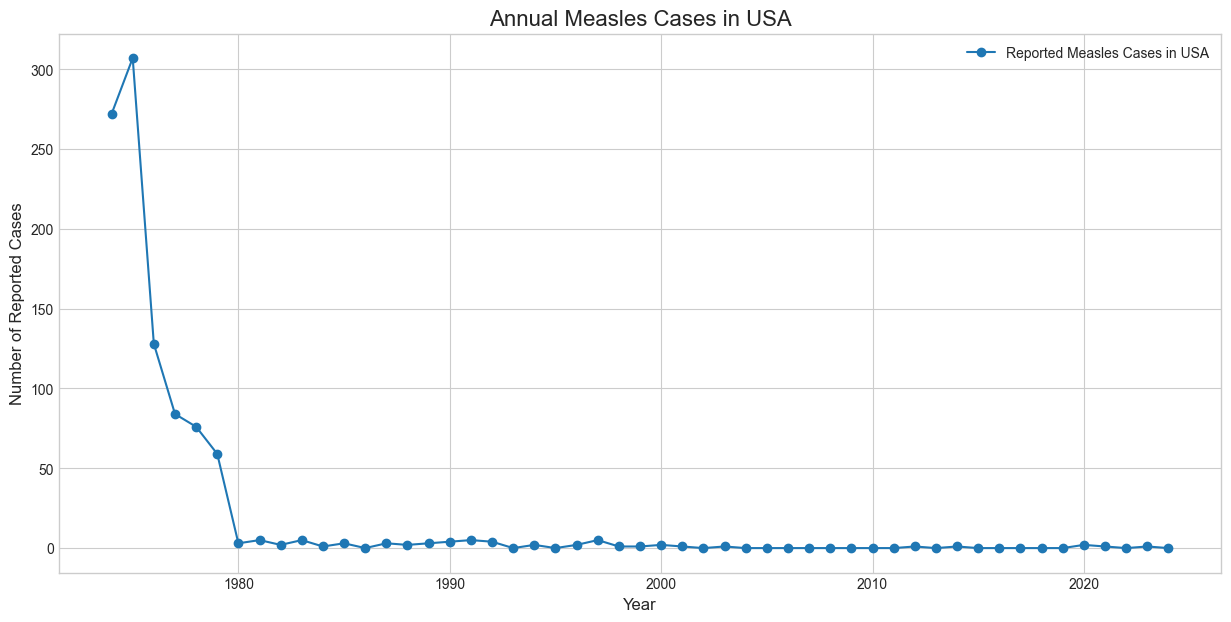

--- Last 5 years of data ---
Year
2020-01-01    2.0
2021-01-01    1.0
2022-01-01    0.0
2023-01-01    1.0
2024-01-01    0.0
Name: USA, dtype: float64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Load the PROCESSED data ---
processed_data_path = '../data/processed/measles_cases_processed_timeseries.csv'
df = pd.read_csv(processed_data_path, index_col='Year', parse_dates=True)

# --- Select data for a single country ---
country_code = 'USA'
ts_usa = df[country_code]

# --- Visualize the time series ---
plt.style.use('seaborn-v0_8-whitegrid') # Sets a nice plot style
plt.figure(figsize=(15, 7))

plt.plot(ts_usa.index, ts_usa.values, marker='o', linestyle='-', label=f'Reported Measles Cases in {country_code}')

plt.title(f'Annual Measles Cases in {country_code}', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Reported Cases', fontsize=12)
plt.legend()
plt.show()

print("--- Last 5 years of data ---")
print(ts_usa.tail())

--- Forecast for the next 5 years ---
2025-01-01    0.394569
2026-01-01    0.838658
2027-01-01    0.687584
2028-01-01    0.541431
2029-01-01    0.772274
Freq: YS-JAN, Name: predicted_mean, dtype: float64


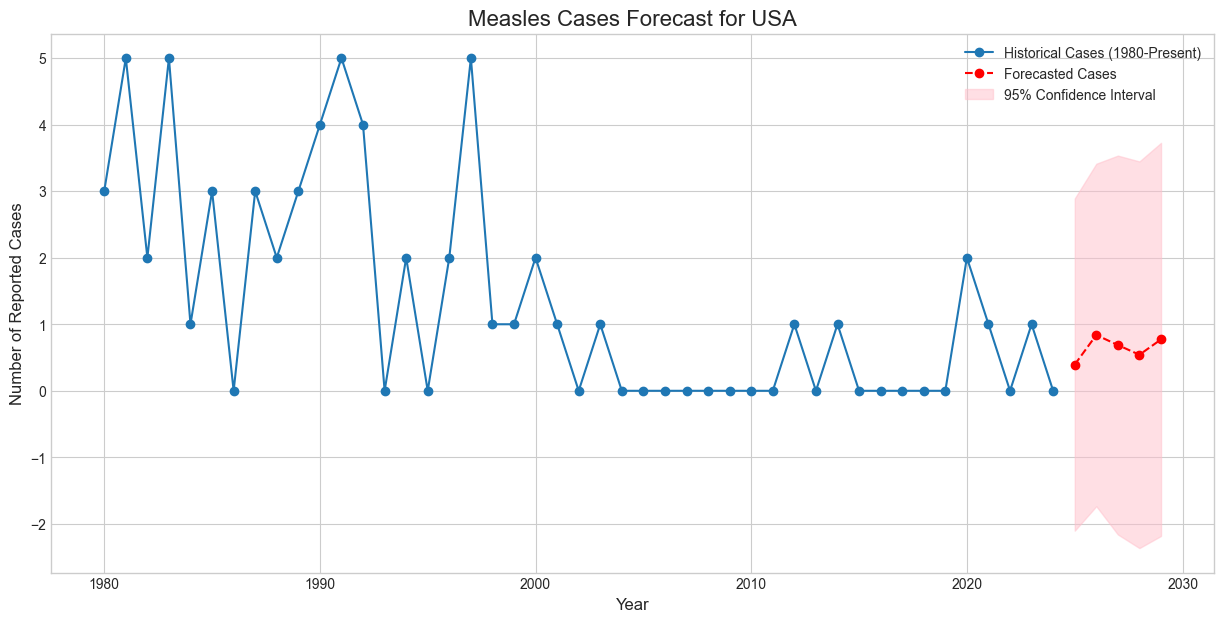

In [2]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore") # Ignore warnings from the model for a cleaner output

# --- Prepare the data ---
# ARIMA works best on stationary data. We'll use the data from 1980 onwards,
# as the pre-vaccine era is a completely different regime.
ts_usa_modern = ts_usa.loc['1980':]

# --- Define and Fit the ARIMA Model ---
# The 'order' (p, d, q) is a key parameter. We'll start with a simple one.
# p=5: Use the last 5 observations (Autoregressive part)
# d=1: Use the difference between consecutive observations (Integrated part)
# q=0: Don't use a moving average component (Moving Average part)
model = ARIMA(ts_usa_modern, order=(5, 1, 0))
model_fit = model.fit()

# --- Generate Forecasts ---
# Let's forecast the next 5 years
forecast_steps = 5
forecast = model_fit.get_forecast(steps=forecast_steps)

# Extract the predicted values and confidence intervals
predicted_values = forecast.predicted_mean
confidence_intervals = forecast.conf_int()

print("--- Forecast for the next 5 years ---")
print(predicted_values)


# --- Visualize the Forecast vs. Actual Data ---
plt.figure(figsize=(15, 7))

# Plot historical data
plt.plot(ts_usa_modern.index, ts_usa_modern.values, label='Historical Cases (1980-Present)', marker='o')

# Plot forecasted values
plt.plot(predicted_values.index, predicted_values, color='red', marker='o', linestyle='--', label='Forecasted Cases')

# Plot confidence intervals (the range of uncertainty)
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1], color='pink', alpha=0.5, label='95% Confidence Interval')

plt.title(f'Measles Cases Forecast for {country_code}', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Reported Cases', fontsize=12)
plt.legend()
plt.show()